# Task 1: pixell validation of the projection + flat-sky Fourier step (SO, signal only)

Plan: `docs/02_test_plan.md` (revision 4). The same input a_ℓm and the same SO coverage go through three pipelines:

| | pipeline | pixels |
|---|---|---|
| **A** | CMBpipeline: HEALPix Q/U → ψ rotation → equidistant projection → interpolation → flat FFT → E/B → flat power spectrum | plane, 704 × 416 |
| **B** | pixell: CAR Q/U → × 2D mask → curved-sky spin-2 `map2alm` → a_E, a_B → `alm2cl` | CAR full sky, 2250 × 1125 |
| **C** | intermediate: rotated CAR patch Q/U → × 2D mask → flat FFT (`enmap.map2harm`) → E/B → flat power spectrum | CAR patch, 708 × 397 |

**References.**
- *Full-sky reference:* `alm2cl` of the input realization.
- *Cut-sky reference* (one per pipeline): the exact true E (or B) field on that pipeline's pixels × its 2D mask, through the same transform. It is what that pipeline would measure if its E/B separation were perfect.

## 0. Set-up

In [1]:
import os, sys, time
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from pixell import enmap, curvedsky, utils
from scipy.spatial import Delaunay
from scipy.ndimage import distance_transform_edt

SRC_DIR = os.path.abspath(os.path.join('..', 'src'))
sys.path.insert(0, SRC_DIR)
import sky_input as si          # input a_lm, spectra, beam
import cmbpipeline_a as pa      # pipeline A: wrappers of ../CMBpipeline/source
import pixell_tools as pt       # mask transfer, rotation, CAR patch
import spectrum_tools as st     # binning, estimators, response shape, paired statistics
import PowerSpectrum as PP      # ../CMBpipeline/source
import utilities                # ../CMBpipeline/source

RESULTS = os.path.abspath(os.path.join('..', 'results', 'task1')); os.makedirs(RESULTS, exist_ok=True)
FIGS = os.path.join(RESULTS, 'figs'); os.makedirs(FIGS, exist_ok=True)
DEG, ARCMIN = np.degrees(1), np.degrees(1) * 60

/home/belen/miniconda3/envs/torch_cmb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---- parameters ---------------------------------------------------------------
nside       = 512                  # HEALPix resolution of pipeline A's input (CMBpipeline)
lmax        = 1535                 # band limit of the input a_lm (3 nside - 1)
fwhm_arcmin = 23.0                 # Gaussian beam, applied to the input a_lm
r           = 0.034                # fiducial tensor-to-scalar ratio (CMBpipeline)

nx, ny, fact = 704, 416, 8         # pipeline A plane grid (9.6' pitch, margin fact * 9.6')
res_car     = 9.6                  # CAR resolution [arcmin] of B and C, matched to the plane pitch
lmax_car    = 1124                 # map2alm band limit on the 9.6' fejer1 grid (1125 rings - 1)
res_car_ctl = 6.0                  # CAR control resolution [arcmin] (1800 rings)
lmax_ctl    = 1535

so_hits_file = '/home/belen/Doctorado/ML/curvesky/polarizacion/norm_nHits_SA_35FOV_ns512.fits'

bins     = utilities.compute_bins_fractional(lmin=4, lmax=1000, frac=0.2, min_width=20)   # CMBpipeline bins
bins_low = np.arange(2, 103, 10)                                                          # low-ell bins
seed_map = 1000                    # single realization
nsims    = 50                      # ensemble: seeds 1000 ... 1049
seeds    = np.arange(seed_map, seed_map + nsims)

print('bins    :', bins)
print('bins_low:', bins_low)

bins    : [   4   24   44   64   84  104  125  150  180  216  259  311  373  447
  537  644  773  927 1113]
bins_low: [  2  12  22  32  42  52  62  72  82  92 102]


In [3]:
# ---- colours and plotting helpers ------------------------------------------------
COL = {'A': '#2a78d6', 'B': '#eb6834', 'C': '#1baf7a', 'Ap': '#eda100', 'B6': '#e87ba4'}
LAB = {'A': 'A  CMBpipeline (plane)', 'B': "B  pixell CAR 9.6' curved sky", 'C': "C  CAR 9.6' + flat FFT",
       'Ap': "A' (FFT with dx=dy=9.6')", 'B6': "B  CAR 6' (control)"}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'lines.linewidth': 2, 'legend.frameon': False,
                     'font.size': 9})

def sym(m, mask=None):
    a = np.asarray(m)
    return 3 * np.std(a[np.asarray(mask) > 0] if mask is not None else a)

def show_img(ax, m, title, extent, xlabel, ylabel, v, mask=None):
    a = np.array(m, dtype=float)
    if mask is not None: a[np.asarray(mask) == 0] = np.nan
    im = ax.imshow(a, origin='lower', extent=extent, cmap='RdBu_r', vmin=-v, vmax=v, aspect='auto', interpolation='nearest')
    ax.set_title(title, fontsize=9); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.grid(False)
    return im

## 1. Reference sky: one set of a_ℓm

CMBpipeline's fiducial C_ℓ, with TE = 0 (`make_dataset._create_spectrum_array`). a_E and a_B are multiplied by the beam B_ℓ once, here. HEALPix (A) and CAR (B, C) maps are only samplings of this field. No pixel window is applied.

Belen's comment: power spectrum of Cl_th and Cl_real (from alm realization)

alm shape: (3, 1180416) | lmax = 1535


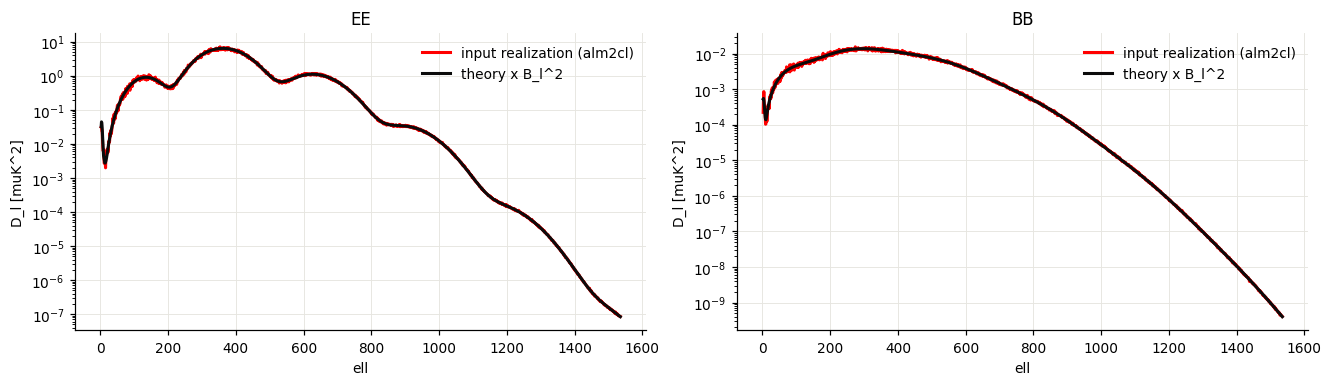

In [4]:
cltt, clee, clbb = si.get_spectra(r, os.path.join(RESULTS, f'cls_signal_r{r}.npy'))
bl = si.beam(fwhm_arcmin, lmax)
ell = np.arange(lmax + 1)

alm = si.make_alm(cltt, clee, clbb, lmax, fwhm_arcmin, seed_map, 'full')        # (a_T, a_E, a_B), beamed
alm_E = si.make_alm(cltt, clee, clbb, lmax, fwhm_arcmin, seed_map, 'E')         # E-only: a_B = 0
print('alm shape:', alm.shape, '| lmax =', lmax)

# full-sky reference spectrum of this realization, and theory C_l B_l^2
cl_real = curvedsky.alm2cl(alm)            # (3,) TT, EE, BB
clee_th, clbb_th = clee[:lmax+1] * bl**2, clbb[:lmax+1] * bl**2

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), constrained_layout=True)
dl = ell * (ell + 1) / (2 * np.pi)
for a, c_th, c_re, name in ((ax[0], clee_th, cl_real[1], 'EE'), (ax[1], clbb_th, cl_real[2], 'BB')):
    a.plot(ell[2:], (dl * c_re)[2:], color='red', label='input realization (alm2cl)')
    a.plot(ell[2:], (dl * c_th)[2:], color='#0b0b0b', label='theory x B_l^2')
    a.set_yscale('log'); a.set_xlabel('ell'); a.set_ylabel('D_l [muK^2]'); a.set_title(name); a.legend()
plt.show()

**Resolution of each representation.** The beam is common. A grid of step Δ represents multipoles up to ℓ_N ≈ π/Δ.

In [5]:
sig = np.radians(fwhm_arcmin / 60) / np.sqrt(8 * np.log(2))
frac_above = lambda c, l: np.sum(((2*ell+1)*c)[l:]) / np.sum(((2*ell+1)*c)[2:])
print(f"beam FWHM {fwhm_arcmin}', sigma {sig*ARCMIN:.2f}'")
print(f"{'representation':34s}{'pixel':>12s}{'l_N':>7s}{'B_l(l_N)':>10s}{'EE var > l_N':>14s}")
for name, d in (('HEALPix nside 512 (A input)', hp.nside2resol(nside)), ("plane 9.6' (A)", 9.6/ARCMIN),
                ("CAR 9.6' in Dec (B, C)", res_car/ARCMIN), ("CAR 6' (control)", res_car_ctl/ARCMIN)):
    lN = int(np.pi / d)
    print(f"{name:34s}{d*ARCMIN:11.2f}'{lN:7d}{bl[min(lN, lmax)]:10.1e}{(frac_above(clee_th, lN) if lN <= lmax else 0):14.1e}")
print('CAR 9.6\' RA step at Dec -25, -47.5, -73 deg:', [round(9.6*np.cos(np.radians(d)), 2) for d in (-25, -47.5, -73)], 'arcmin')

beam FWHM 23.0', sigma 9.77'
representation                           pixel    l_N  B_l(l_N)  EE var > l_N
HEALPix nside 512 (A input)              6.87'   1571   7.4e-05       0.0e+00
plane 9.6' (A)                           9.60'   1125   6.0e-03       6.0e-06
CAR 9.6' in Dec (B, C)                   9.60'   1125   6.0e-03       6.0e-06
CAR 6' (control)                         6.00'   1800   7.4e-05       0.0e+00
CAR 9.6' RA step at Dec -25, -47.5, -73 deg: [np.float64(8.7), np.float64(6.49), np.float64(2.81)] arcmin


## 2. Common coverage

The SO region is defined once on the sphere (`make_SO_mask`: hits > 0.25 within 100° of the maximum). It is transferred to each geometry with the same rule: each pixel centre takes the value of the HEALPix pixel that contains it.

In [6]:
# A: CMBpipeline SO geometry (same calls as geometry.build_geometry)
geo = pa.so_geometry(nside, nx, ny, fact, so_hits_file)
mask_hp, mask2d = geo['mask'], geo['mask2d']
print(f"A plane: nx x ny = {nx} x {ny},  pitch {geo['pix']*ARCMIN:.2f}',  FFT dx = {geo['dx']*ARCMIN:.3f}', dy = {geo['dy']*ARCMIN:.3f}'")

# B: full-sky CAR (fejer1) at 9.6' and the transferred mask
shape_B, wcs_B = enmap.fullsky_geometry(res=res_car * utils.arcmin, variant='fejer1')
mask_B = pt.car_mask(shape_B, wcs_B, mask_hp, nside)
print(f"B CAR  : nx x ny = {shape_B[1]} x {shape_B[0]} (RA x Dec, full sky), method = {curvedsky.get_method(shape_B, wcs_B)}")

# C: rotate the patch centre to (0, 0), CAR patch sliced from the 9.6' fejer1 sky, same margin as A
angles, R = pt.rotation_to_equator(geo['lonc'], geo['latc'])
shape_C, wcs_C = pt.patch_geometry(geo['vecs'], R, res_car, fact * 9.6)
mask_C = pt.car_mask(shape_C, wcs_C, mask_hp, nside, R=R)
print(f"C patch: nx x ny = {shape_C[1]} x {shape_C[0]} (rotated RA x Dec)")

# B control: 6' CAR
shape_B6, wcs_B6 = enmap.fullsky_geometry(res=res_car_ctl * utils.arcmin, variant='fejer1')
mask_B6 = pt.car_mask(shape_B6, wcs_B6, mask_hp, nside)

# weights w2 = <mask^2>: flat mean for A and C, area weighted on the sphere for B
w2_A, w2_C = np.mean(mask2d**2), np.mean(np.asarray(mask_C)**2)
w2_B, w2_B6 = pt.w2_car(mask_B), pt.w2_car(mask_B6)
jac = np.sin(np.hypot(geo['grid_x'], geo['grid_y'])) / np.hypot(geo['grid_x'], geo['grid_y'])   # equidistant dOmega = sin(r)/r dx dy
area = lambda pix_area: np.sum(pix_area) * DEG**2
print()
print(f"{'':28s}{'observed pix':>13s}{'area [deg2]':>13s}{'w2':>9s}")
print(f"{'HEALPix (definition)':28s}{int(mask_hp.sum()):13d}{mask_hp.sum()*hp.nside2pixarea(nside)*DEG**2:13.1f}{mask_hp.mean():9.4f}")
print(f"{'A plane (flat 9.6 pix)':28s}{int(mask2d.sum()):13d}{area(mask2d*geo['pix']**2):13.1f}{w2_A:9.4f}")
print(f"{'A plane (true solid angle)':28s}{'':13s}{area(mask2d*geo['pix']**2*jac):13.1f}")
print(f"{'B CAR 9.6':28s}{int(mask_B.sum()):13d}{area(mask_B*mask_B.pixsizemap()):13.1f}{w2_B:9.4f}")
print(f"{'C CAR patch 9.6':28s}{int(mask_C.sum()):13d}{area(mask_C*mask_C.pixsizemap()):13.1f}{w2_C:9.4f}")
print(f"{'B control CAR 6':28s}{int(mask_B6.sum()):13d}{area(mask_B6*mask_B6.pixsizemap()):13.1f}{w2_B6:9.4f}")

A plane: nx x ny = 704 x 416,  pitch 9.60',  FFT dx = 9.553', dy = 9.315'
B CAR  : nx x ny = 2250 x 1125 (RA x Dec, full sky), method = 2d
C patch: nx x ny = 708 x 397 (rotated RA x Dec)

                             observed pix  area [deg2]       w2
HEALPix (definition)               349440       4582.5   0.1111
A plane (flat 9.6 pix)             189097       4840.9   0.6457
A plane (true solid angle)                      4582.6
B CAR 9.6                          286159       4582.8   0.1111
C CAR patch 9.6                    186278       4583.0   0.6627
B control CAR 6                    732493       4582.3   0.1111


B CAR  : nx x ny = 2250 x 1125 (RA x Dec, full sky), method = 2d
C patch: nx x ny = 708 x 397 (rotated RA x Dec)



                             observed pix  area [deg2]       w2
HEALPix (definition)               349440       4582.5   0.1111
A plane (flat 9.6 pix)             189097       4840.9   0.6457
A plane (true solid angle)                      4582.6
B CAR 9.6                          286159       4582.8   0.1111
C CAR patch 9.6                    186278       4583.0   0.6627
B control CAR 6                    732493       4582.3   0.1111


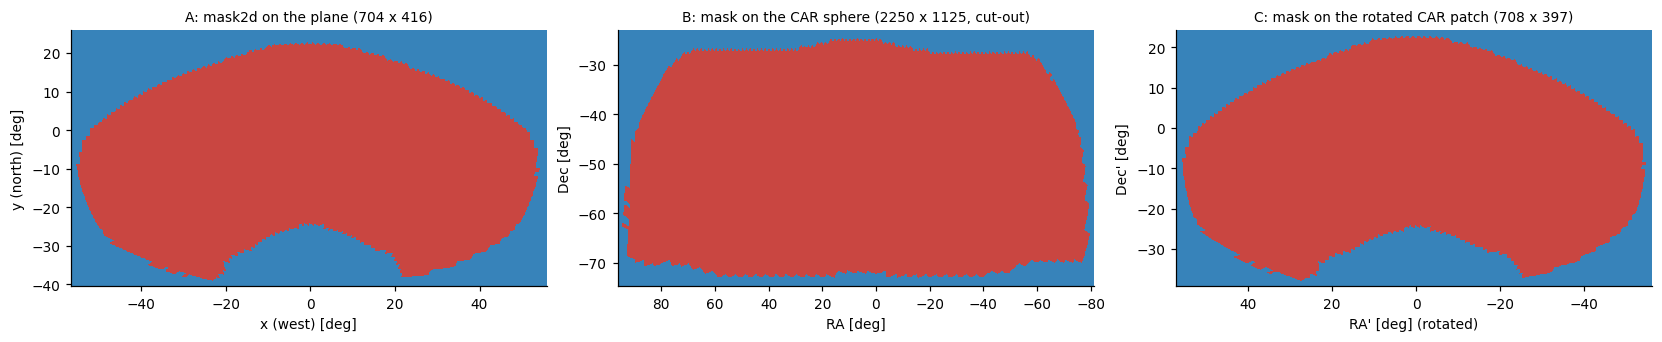

In [7]:
# extents for plotting
EXT_A = [geo['x_vals'][0]*DEG, geo['x_vals'][-1]*DEG, geo['y_vals'][0]*DEG, geo['y_vals'][-1]*DEG]
ys, xs = np.nonzero(np.asarray(mask_B) > 0)
cut_B = (slice(ys.min() - 10, ys.max() + 11), slice(xs.min() - 10, xs.max() + 11))
box = enmap.pix2sky(shape_B, wcs_B, [[cut_B[0].start, cut_B[0].stop - 1], [cut_B[1].start, cut_B[1].stop - 1]]) * DEG
EXT_B = [box[1][0], box[1][1], box[0][0], box[0][1]]
boxC = enmap.box(shape_C, wcs_C) * DEG
EXT_C = [boxC[0][1], boxC[1][1], boxC[0][0], boxC[1][0]]
plotA = lambda ax, m, t, v, mk=mask2d: show_img(ax, m, t, EXT_A, 'x (west) [deg]', 'y (north) [deg]', v, mk)
plotB = lambda ax, m, t, v, mk=mask_B: show_img(ax, np.asarray(m)[cut_B], t, EXT_B, 'RA [deg]', 'Dec [deg]', v, None if mk is None else np.asarray(mk)[cut_B])
plotC = lambda ax, m, t, v, mk=mask_C: show_img(ax, m, t, EXT_C, "RA' [deg] (rotated)", "Dec' [deg]", v, mk)

fig, ax = plt.subplots(1, 3, figsize=(15, 3), constrained_layout=True)
plotA(ax[0], mask2d * 2 - 1, f'A: mask2d on the plane ({nx} x {ny})', 1.5, None)
plotB(ax[1], np.asarray(mask_B) * 2 - 1, f'B: mask on the CAR sphere ({shape_B[1]} x {shape_B[0]}, cut-out)', 1.5, None)
plotC(ax[2], np.asarray(mask_C) * 2 - 1, f'C: mask on the rotated CAR patch ({shape_C[1]} x {shape_C[0]})', 1.5, None)
plt.savefig(f'{FIGS}/01_masks.png', dpi=150); plt.show()

## 3. Pipeline A step by step (seed 1000, full input)

All calls are CMBpipeline functions. The interpolation uses a cached Delaunay triangulation; the output is checked below to be identical to `grid_bins_mask_from_res_margin`.

cached triangulation == CMBpipeline griddata: True
time: alm2map 0.68 s | rotate+project+interpolate 10.64 s (griddata), 2.79 s (cached) | E/B 0.024 s


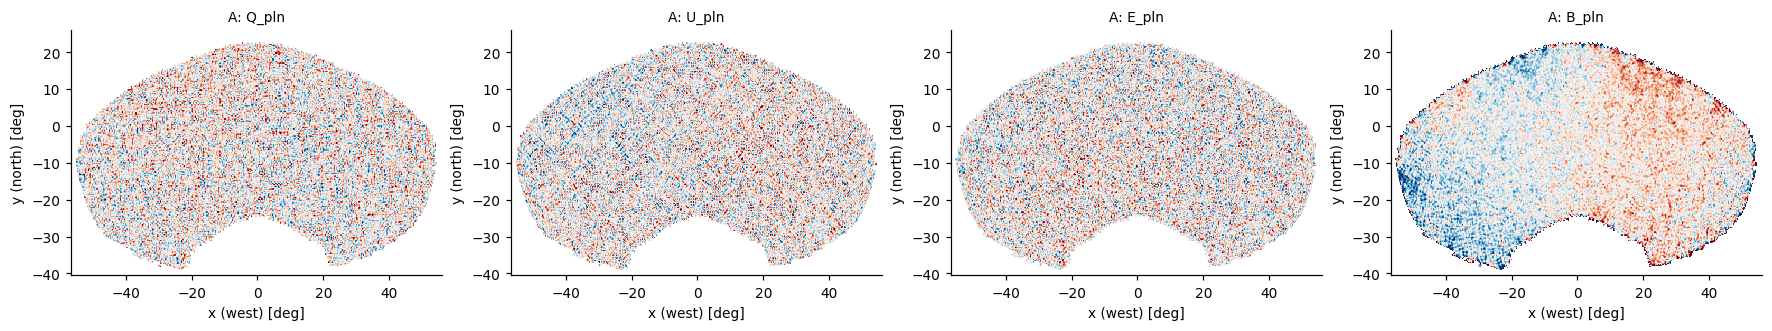

In [8]:
t0 = time.time()
Q_sph, U_sph = hp.alm2map(alm, nside, lmax=lmax, pol=True)[1:]            # a_lm -> Q, U on HEALPix
t_A1 = time.time() - t0

t0 = time.time()
Q_pln_ref, U_pln_ref = pa.qu_to_plane(geo, Q_sph, U_sph)                  # CMBpipeline griddata (as in the pipeline)
t_A2_griddata = time.time() - t0

tri = Delaunay(geo['z_eq'])                                               # once
t0 = time.time()
Q_pln, U_pln = pa.qu_to_plane(geo, Q_sph, U_sph, tri)                     # same interpolant, triangulation reused
t_A2 = time.time() - t0
print('cached triangulation == CMBpipeline griddata:', np.array_equal(Q_pln, Q_pln_ref) and np.array_equal(U_pln, U_pln_ref))

t0 = time.time()
E_pln, B_pln = pa.plane_eb(Q_pln, U_pln, nx, ny, geo['dx'], geo['dy'])    # transf_eb2_np + irfft2/tfac
t_A3 = time.time() - t0
print(f'time: alm2map {t_A1:.2f} s | rotate+project+interpolate {t_A2_griddata:.2f} s (griddata), {t_A2:.2f} s (cached) | E/B {t_A3:.3f} s')

vQ = sym(Q_pln, mask2d)
fig, ax = plt.subplots(1, 4, figsize=(16, 2.9), constrained_layout=True)
plotA(ax[0], Q_pln, 'A: Q_pln', vQ); plotA(ax[1], U_pln, 'A: U_pln', vQ)
plotA(ax[2], E_pln, 'A: E_pln', sym(E_pln, mask2d)); plotA(ax[3], B_pln, 'A: B_pln', sym(B_pln, mask2d))
plt.savefig(f'{FIGS}/02_pipeline_A.png', dpi=150); plt.show()

## 4. Pipeline B step by step

- `curvedsky.alm2map(spin=2)`: exact spin-2 synthesis. Q/U are in the local (θ, φ) basis with the HEALPix sign convention, the same as healpy (checked below).
- `curvedsky.map2alm(spin=2)` on the fejer1 grid uses exact quadrature up to ℓ = 1124. With the mask it returns the a_E, a_B of the cut sky.

In [9]:
# convention check: pixell and healpy synthesize the same Q, U (same polarization basis and sign)
pix = np.random.default_rng(0).integers(0, hp.nside2npix(nside), 5000)
th, ph = hp.pix2ang(nside, pix)
qu_pos = curvedsky.alm2map_pos(alm[1:], pos=np.array([np.pi/2 - th, ph]), spin=2)
print('max |pixell - healpy| / std:  Q %.1e,  U %.1e' % (np.abs(qu_pos[0] - Q_sph[pix]).max() / Q_sph.std(),
                                                      np.abs(qu_pos[1] - U_sph[pix]).max() / U_sph.std()))
# exactness of map2alm on the 9.6' fejer1 grid below lmax_car
a_test = curvedsky.rand_alm(np.ones(lmax_car + 1), lmax=lmax_car, seed=1)
back = curvedsky.map2alm(curvedsky.alm2map(a_test, enmap.zeros(shape_B, wcs_B), spin=0), lmax=lmax_car, spin=0)
print(f'9.6 arcmin fejer1 round trip up to l = {lmax_car}: max rel error {np.abs(back - a_test).max()/np.abs(a_test).max():.1e}')

max |pixell - healpy| / std:  Q 1.0e-12,  U 9.7e-13
9.6 arcmin fejer1 round trip up to l = 1124: max rel error 2.2e-12


time: alm2map 0.35 s | map2alm 0.31 s


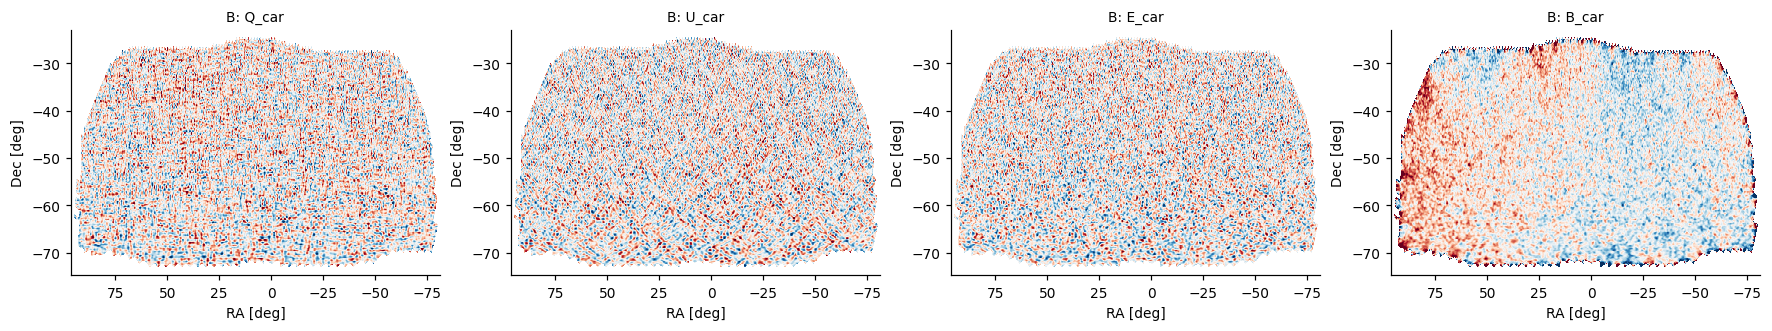

In [10]:
t0 = time.time()
QU_car = curvedsky.alm2map(alm[1:], enmap.zeros((2,) + shape_B, wcs_B), spin=2)     # a_lm -> Q, U on CAR
t_B1 = time.time() - t0
t0 = time.time()
alm_EB = curvedsky.map2alm(QU_car * mask_B, lmax=lmax_car, spin=2)                   # masked spin-2 analysis -> a_E, a_B
t_B2 = time.time() - t0
EB_car = curvedsky.alm2map(alm_EB, enmap.zeros((2,) + shape_B, wcs_B), spin=0)      # E, B maps (for inspection)
print(f'time: alm2map {t_B1:.2f} s | map2alm {t_B2:.2f} s')

fig, ax = plt.subplots(1, 4, figsize=(16, 2.9), constrained_layout=True)
plotB(ax[0], QU_car[0], 'B: Q_car', vQ); plotB(ax[1], QU_car[1], 'B: U_car', vQ)
plotB(ax[2], EB_car[0], 'B: E_car', sym(EB_car[0], mask_B)); plotB(ax[3], EB_car[1], 'B: B_car', sym(EB_car[1], mask_B))
plt.savefig(f'{FIGS}/03_pipeline_B.png', dpi=150); plt.show()

## 5. Pipeline C step by step

The flat FFT needs the patch near the equator. In equatorial CAR the patch spans Dec −73°…−25°, so the RA pixel width (∝ cos Dec) changes by a factor 3. `rotate_alm` moves the patch centre to (0, 0), which is exact for E and B. The CAR grid axes follow the local meridians, so Q/U are already in the grid frame.

In [11]:
# check the rotation: T'(R n) = T(n) at random points
rng = np.random.default_rng(1)
pos = np.array([rng.uniform(-1.2, -0.5, 300), rng.uniform(-1.0, 1.2, 300)])
vec = np.stack([np.cos(pos[0])*np.cos(pos[1]), np.cos(pos[0])*np.sin(pos[1]), np.sin(pos[0])], -1) @ R.T
pos_rot = np.array([np.arcsin(vec[:, 2]), np.arctan2(vec[:, 1], vec[:, 0])])
alm_rot = curvedsky.rotate_alm(alm, *angles)
d = curvedsky.alm2map_pos(alm[0], pos=pos, spin=0) - curvedsky.alm2map_pos(alm_rot[0], pos=pos_rot, spin=0)
print(f'rotation check: max |T(n) - T\'(R n)| / std = {np.abs(d).max()/np.std(curvedsky.alm2map_pos(alm[0], pos=pos, spin=0)):.1e}')
decC = enmap.posmap(shape_C, wcs_C)[0][np.asarray(mask_C) > 0]
print(f'rotated patch: Dec in [{decC.min()*DEG:.1f}, {decC.max()*DEG:.1f}] deg, cos(Dec) ratio {np.cos(decC).max()/np.cos(decC).min():.2f}')

rotation check: max |T(n) - T'(R n)| / std = 2.6e-12
rotated patch: Dec in [-37.9, 22.7] deg, cos(Dec) ratio 1.27


time: rotate + alm2map + map2harm 1.51 s


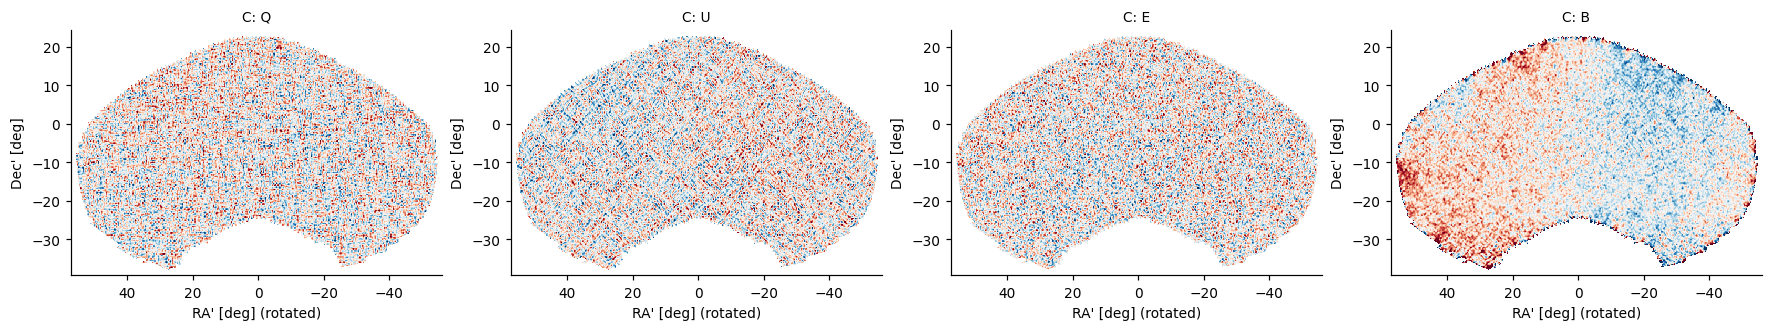

In [12]:
t0 = time.time()
alm_rot = curvedsky.rotate_alm(alm, *angles)                                          # patch centre -> (0, 0)
QU_C = curvedsky.alm2map(alm_rot[1:], enmap.zeros((2,) + shape_C, wcs_C), spin=2)   # Q, U on the CAR patch
harm_C = enmap.map2harm(QU_C * mask_C, normalize='phys', spin=[2])                   # flat FFT, Q/U -> E/B (HEALPix convention)
EB_C = enmap.ifft(harm_C, normalize='phys').real                                     # E, B maps
t_C = time.time() - t0
print(f'time: rotate + alm2map + map2harm {t_C:.2f} s')

fig, ax = plt.subplots(1, 4, figsize=(16, 2.9), constrained_layout=True)
plotC(ax[0], QU_C[0], 'C: Q', vQ); plotC(ax[1], QU_C[1], 'C: U', vQ)
plotC(ax[2], EB_C[0], 'C: E', sym(EB_C[0], mask_C)); plotC(ax[3], EB_C[1], 'C: B', sym(EB_C[1], mask_C))
plt.savefig(f'{FIGS}/04_pipeline_C.png', dpi=150); plt.show()

## 6. True E/B on each pipeline's pixels, and A's sign

True E, B = the spin-0 synthesis of a_E, a_B:
- A: exactly at the plane grid points, through the inverse equidistant map and `alm2map_pos`.
- B: on the CAR grid.
- C: on the rotated patch.

In [13]:
pos_A = pa.grid_positions(geo)
EB_true_A = curvedsky.alm2map_pos(alm[1:], pos=pos_A.reshape(2, -1), spin=0).reshape(2, ny, nx)
EB_true_B = curvedsky.alm2map(alm[1:], enmap.zeros((2,) + shape_B, wcs_B), spin=0)
EB_true_C = curvedsky.alm2map(alm_rot[1:], enmap.zeros((2,) + shape_C, wcs_C), spin=0)

mA, mB, mC = mask2d > 0, np.asarray(mask_B) > 0, np.asarray(mask_C) > 0
corr = lambda a, b, m: np.corrcoef(np.asarray(a)[m], np.asarray(b)[m])[0, 1]
print(f'corr(E, E_true) inside the mask:  A {corr(E_pln, EB_true_A[0], mA):+.4f}   B {corr(EB_car[0], EB_true_B[0], mB):+.4f}   C {corr(EB_C[0], EB_true_C[0], mC):+.4f}')
sign_A = np.sign(corr(E_pln, EB_true_A[0], mA))
print('A\'s E/B come out with sign', sign_A, 'w.r.t. healpy/pixell (Phase 1 prediction). Maps of A are multiplied by it; spectra are unaffected.')
res = lambda a, b, m: np.sqrt(np.mean((np.asarray(a)[m] - np.asarray(b)[m])**2)) / np.std(np.asarray(b)[m])
print(f'RMS(E - E_true)/RMS(E_true) inside the mask:  A {res(sign_A*E_pln, EB_true_A[0], mA):.4f}   B {res(EB_car[0], EB_true_B[0], mB):.4f}   C {res(EB_C[0], EB_true_C[0], mC):.4f}')

corr(E, E_true) inside the mask:  A -0.9961   B +0.9964   C +0.9961
A's E/B come out with sign -1.0 w.r.t. healpy/pixell (Phase 1 prediction). Maps of A are multiplied by it; spectra are unaffected.
RMS(E - E_true)/RMS(E_true) inside the mask:  A 0.0918   B 0.0860   C 0.0931


## 6b. Pipeline B on the cut-out region (smaller array, still curved sky)

The same steps as pipeline B, but every array covers only the region that contains `mask_B` (the cut-out shown in section 2) instead of the whole sphere:

1. Q, U synthesized with `curvedsky.alm2map` directly on the cut-out geometry.
2. Multiply by the mask on the cut-out.
3. `curvedsky.map2alm(spin=2, method='2d')` gives a_E, a_B. The cut-out is a slice of the 9.6′ fejer1 full-sky grid, so pixell pads it with zeros back to the sphere and uses the exact ring quadrature.
4. `curvedsky.alm2map(spin=0)` gives the E and B maps on the same cut-out.

At no step is the map treated as a plane.

In [14]:
# cut-out geometry: the rows/columns of the full-sky CAR grid that contain mask_B (cut_B, section 2)
shape_cut, wcs_cut = mask_B[cut_B].geometry
mask_cut = mask_B[cut_B]
print(f'full sphere : nx x ny = {shape_B[1]} x {shape_B[0]} = {shape_B[0]*shape_B[1]:,} pixels')
print(f'cut-out     : nx x ny = {shape_cut[1]} x {shape_cut[0]} = {shape_cut[0]*shape_cut[1]:,} pixels '
      f'({shape_cut[0]*shape_cut[1]/(shape_B[0]*shape_B[1])*100:.0f} % of the sphere), observed {int(mask_cut.sum()):,}')

t0 = time.time()
QU_cut = curvedsky.alm2map(alm[1:], enmap.zeros((2,) + shape_cut, wcs_cut), spin=2)        # 1. Q, U on the cut-out
alm_EB_cut = curvedsky.map2alm(QU_cut * mask_cut, lmax=lmax_car, spin=2, method='2d')      # 2-3. mask, curved-sky E/B
EB_cut = curvedsky.alm2map(alm_EB_cut, enmap.zeros((2,) + shape_cut, wcs_cut), spin=0)     # 4. E, B maps on the cut-out
t_Bcut = time.time() - t0
print(f'time: {t_Bcut:.2f} s (full-sky B: alm2map {t_B1:.2f} s + map2alm {t_B2:.2f} s)')
print('QU_cut:', QU_cut.shape, '  EB_cut:', EB_cut.shape)

full sphere : nx x ny = 2250 x 1125 = 2,531,250 pixels
cut-out     : nx x ny = 1110 x 324 = 359,640 pixels (14 % of the sphere), observed 286,159
time: 0.53 s (full-sky B: alm2map 0.35 s + map2alm 0.31 s)
QU_cut: (2, 324, 1110)   EB_cut: (2, 324, 1110)


time: 0.37 s (full-sky B: alm2map 0.24 s + map2alm 0.21 s)
QU_cut: (2, 324, 1110)   EB_cut: (2, 324, 1110)


In [15]:
# comparison with the full-sky pipeline B on the same pixels
rel = lambda a, b: np.abs(np.asarray(a) - np.asarray(b)).max() / np.abs(np.asarray(b)).max()
print(f'Q/U  : max |QU_cut - QU_car[cut]| / max       = {rel(QU_cut, QU_car[(slice(None),) + cut_B]):.1e}')
print(f'a_lm : max |a_cut - a_fullsky| / max           = {rel(alm_EB_cut, alm_EB):.1e}')
print(f'E/B  : max |EB_cut - EB_car[cut]| / max         = {rel(EB_cut, EB_car[(slice(None),) + cut_B]):.1e}')
cl_cut, cl_fullsky = curvedsky.alm2cl(alm_EB_cut), curvedsky.alm2cl(alm_EB)
print(f'C_l  : max |C_l(cut)/C_l(full sky) - 1| (2 <= l <= 1124): EE {np.abs(cl_cut[0,2:]/cl_fullsky[0,2:]-1).max():.1e}, BB {np.abs(cl_cut[1,2:]/cl_fullsky[1,2:]-1).max():.1e}')
mcut = np.asarray(mask_cut) > 0
print(f'RMS(E - E_true)/RMS(E_true) in the mask: cut-out {res(EB_cut[0], EB_true_B[0][cut_B], mcut):.4f}   full sky {res(EB_car[0], EB_true_B[0], mB):.4f}')

# why method='2d': the default for a partial map ('cyl') uses approximate ring weights
a_cyl = curvedsky.map2alm(QU_cut * mask_cut, lmax=lmax_car, spin=2, method='cyl')
print(f"with method='cyl' instead: max |a - a_fullsky| / max = {rel(a_cyl, alm_EB):.1e}")

Q/U  : max |QU_cut - QU_car[cut]| / max       = 1.2e-13
a_lm : max |a_cut - a_fullsky| / max           = 1.6e-14
E/B  : max |EB_cut - EB_car[cut]| / max         = 1.7e-13
C_l  : max |C_l(cut)/C_l(full sky) - 1| (2 <= l <= 1124): EE 7.2e-14, BB 1.0e-13
RMS(E - E_true)/RMS(E_true) in the mask: cut-out 0.0860   full sky 0.0860
with method='cyl' instead: max |a - a_fullsky| / max = 4.0e-04


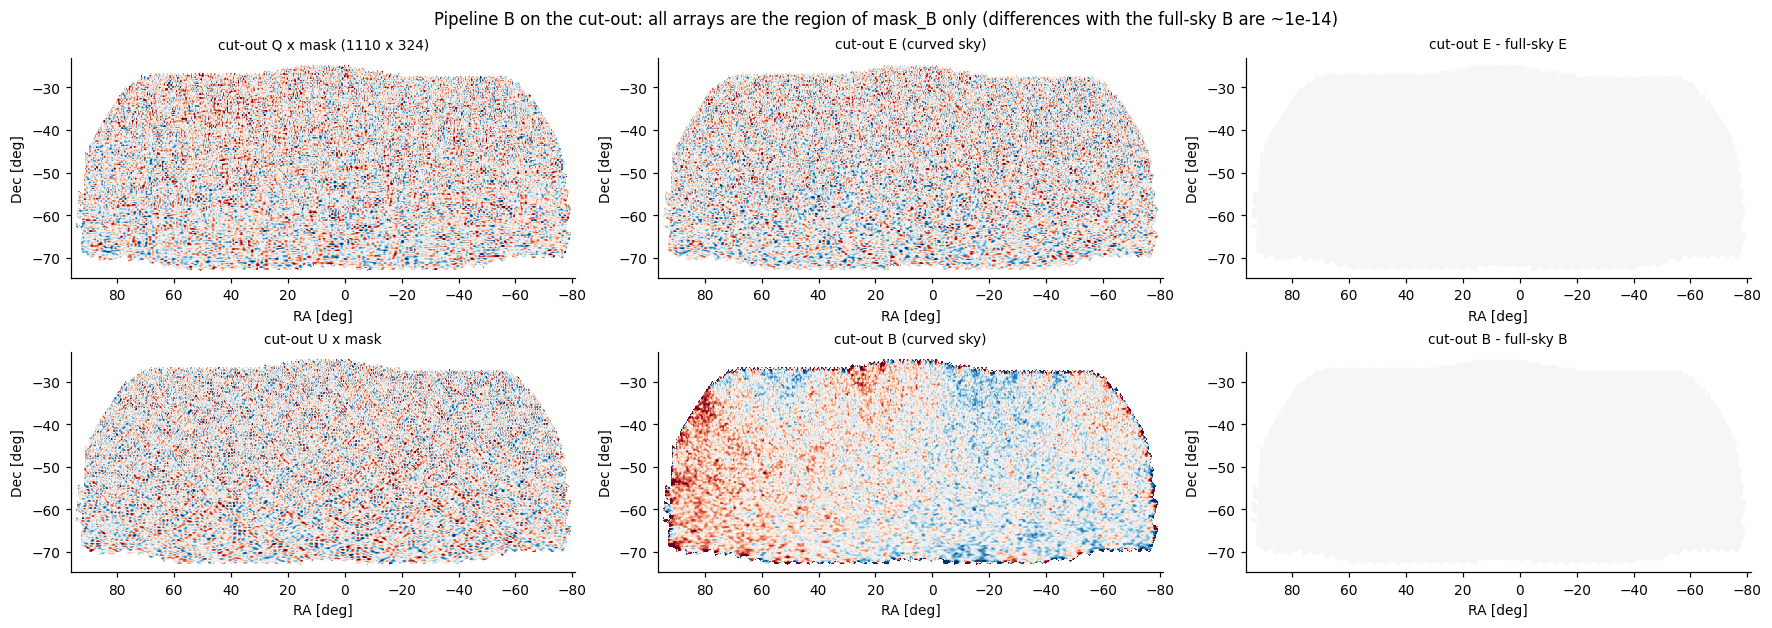

In [16]:
ext_cut = EXT_B       # same region as the display cut-out of section 2
plotcut = lambda ax, m, t, v, mk=mask_cut: show_img(ax, m, t, ext_cut, 'RA [deg]', 'Dec [deg]', v, mk)
fig, ax = plt.subplots(2, 3, figsize=(16, 5.6), constrained_layout=True)
plotcut(ax[0, 0], QU_cut[0] * mask_cut, f'cut-out Q x mask ({shape_cut[1]} x {shape_cut[0]})', vQ)
plotcut(ax[0, 1], EB_cut[0], 'cut-out E (curved sky)', sym(EB_cut[0], mask_cut))
plotcut(ax[0, 2], EB_cut[0] - EB_car[0][cut_B], 'cut-out E - full-sky E', sym(EB_cut[0], mask_cut) / 5)
plotcut(ax[1, 0], QU_cut[1] * mask_cut, 'cut-out U x mask', vQ)
plotcut(ax[1, 1], EB_cut[1], 'cut-out B (curved sky)', sym(EB_cut[1], mask_cut))
plotcut(ax[1, 2], EB_cut[1] - EB_car[1][cut_B], 'cut-out B - full-sky B', sym(EB_cut[1], mask_cut) / 5)
fig.suptitle('Pipeline B on the cut-out: all arrays are the region of mask_B only (differences with the full-sky B are ~1e-14)')
plt.savefig(f'{FIGS}/04b_B_cutout.png', dpi=150); plt.show()

## 7. E/B leakage (E-only realization, seed 1000)

a_B = 0, so every recovered B mode is leakage. B's leakage is the cut-sky mixing of the common footprint. What matters is the *excess* of A and C over B.

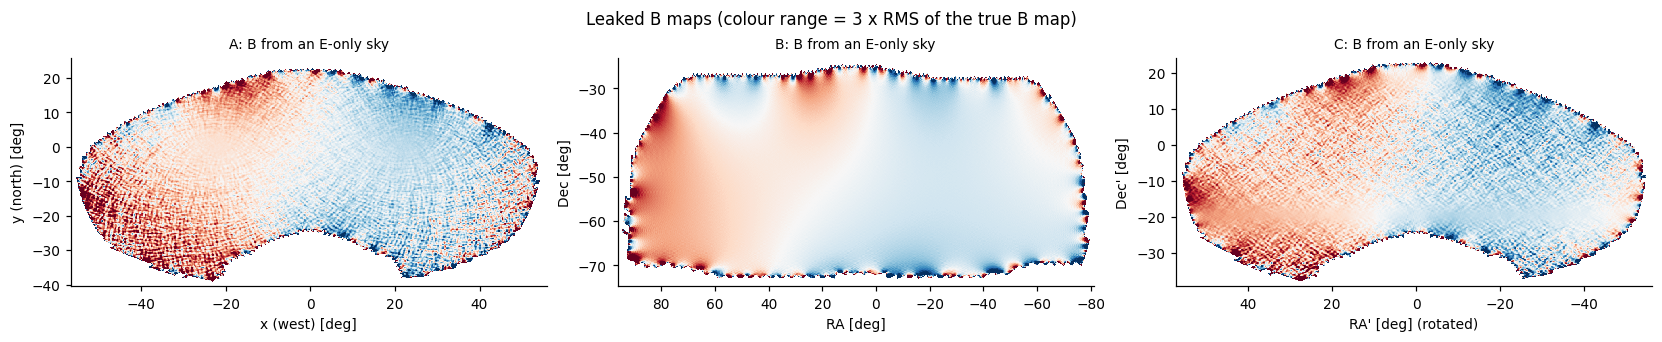

In [17]:
# A 
# generación Q,U maps, projection to Q,U plane maps, transformación a E,B usando dx, dy
Q_sph_E, U_sph_E = hp.alm2map(alm_E, nside, lmax=lmax, pol=True)[1:]
Q_pln_E, U_pln_E = pa.qu_to_plane(geo, Q_sph_E, U_sph_E, tri)
E_pln_E, B_pln_E = pa.plane_eb(Q_pln_E, U_pln_E, nx, ny, geo['dx'], geo['dy'])
# B
# alm2map to generate QU maps, transform to EB with map2alm, alm2map (I think is considering pixel size unequal area)
QU_car_E = curvedsky.alm2map(alm_E[1:], enmap.zeros((2,) + shape_B, wcs_B), spin=2)
alm_EB_E = curvedsky.map2alm(QU_car_E * mask_B, lmax=lmax_car, spin=2)
EB_car_E = curvedsky.alm2map(alm_EB_E, enmap.zeros((2,) + shape_B, wcs_B), spin=0)
# C
alm_rot_E = curvedsky.rotate_alm(alm_E, *angles)
QU_C_E = curvedsky.alm2map(alm_rot_E[1:], enmap.zeros((2,) + shape_C, wcs_C), spin=2)
harm_C_E = enmap.map2harm(QU_C_E * mask_C, normalize='phys', spin=[2])
EB_C_E = enmap.ifft(harm_C_E, normalize='phys').real

vB = sym(EB_true_B[1], mask_B)        # colour scale: the TRUE B signal of the full input
fig, ax = plt.subplots(1, 3, figsize=(15, 3), constrained_layout=True)
plotA(ax[0], sign_A * B_pln_E, 'A: B from an E-only sky', vB)
plotB(ax[1], EB_car_E[1], 'B: B from an E-only sky', vB)
plotC(ax[2], EB_C_E[1], 'C: B from an E-only sky', vB)
fig.suptitle('Leaked B maps (colour range = 3 x RMS of the true B map)'); plt.savefig(f'{FIGS}/05_leak_maps.png', dpi=150); plt.show()

In [18]:
# it contrains the entire sphere but display only a cut

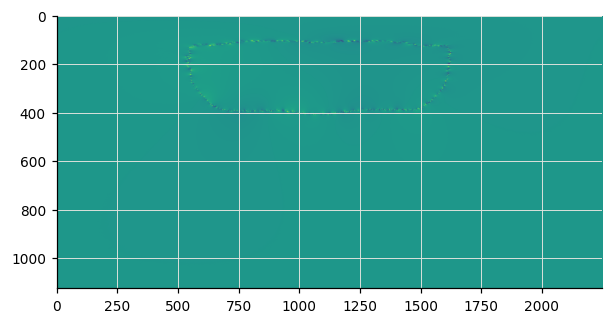

In [19]:
plt.imshow(EB_car_E[1])

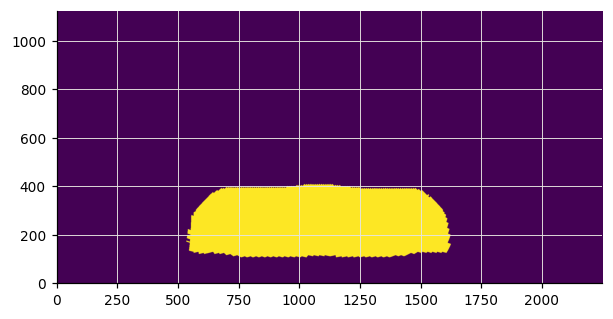

In [20]:
plt.imshow(mask_B, origin='lower')

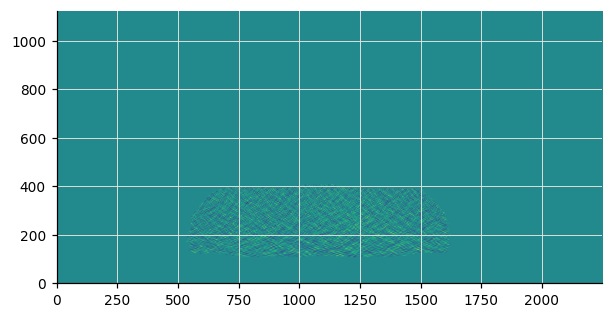

In [21]:
plt.imshow(QU_car_E[1]*mask_B, origin='lower')
#plt.colorbar()

In [18]:
# where does the leakage sit: RMS(B leaked)/RMS(E_true) vs distance to the mask edge
bands = [0, 1, 2, 4, 8, 90]
dist_A = distance_transform_edt(mA) * geo['pix']                                   # plane distance (A)
dist_B = np.zeros(shape_B); dist_B[cut_B] = enmap.distance_transform(mask_B[cut_B] > 0)
dist_C = np.asarray(enmap.distance_transform(mask_C > 0))
def edge_profile(Bmap, Etrue, m, dist):
    rE = np.std(np.asarray(Etrue)[m])
    return [np.sqrt(np.mean(np.asarray(Bmap)[m & (dist >= np.radians(a)) & (dist < np.radians(b))]**2)) / rE
            for a, b in zip(bands[:-1], bands[1:])]
prof = {'A': edge_profile(B_pln_E, EB_true_A[0], mA, dist_A),
        'B': edge_profile(EB_car_E[1], EB_true_B[0], mB, dist_B),
        'C': edge_profile(EB_C_E[1], EB_true_C[0], mC, dist_C)}
lab_b = ['0-1', '1-2', '2-4', '4-8', '>8']
print('distance to edge [deg]:', lab_b)
for k, v in prof.items(): print(f'{k}: ', np.round(v, 4))

distance to edge [deg]: ['0-1', '1-2', '2-4', '4-8', '>8']
A:  [0.2913 0.1145 0.0955 0.0799 0.0523]
B:  [0.2634 0.0844 0.0651 0.0528 0.0349]
C:  [0.2768 0.1008 0.0816 0.0673 0.0556]


In [20]:
# leakage spectra (seed 1000)
ps_A = PP.PowerSpectrum(nside, nx, ny, geo['dx'], geo['dy'], fwhm_arcmin, len(bins) - 1, bins, 1.0, 5e-7)
ell_flat, _ = ps_A.flat_spectrum_xy(clee)                  # ell = |k| of every Fourier mode (CMBpipeline)
modl_C = harm_C.modlmap()

def spectra_A(E, B, b):  return st.flat_spectrum_A(ps_A, E, ell_flat, b, w2_A), st.flat_spectrum_A(ps_A, B, ell_flat, b, w2_A)
def spectra_B(aEB, b, w2=w2_B): return st.curved_spectrum(aEB[0], b, w2), st.curved_spectrum(aEB[1], b, w2)
def spectra_C(h, b):     return st.flat_spectrum_enmap(h[0], modl_C, b, w2_C), st.flat_spectrum_enmap(h[1], modl_C, b, w2_C)

lb, lb_low = 0.5 * (bins[1:] + bins[:-1]), 0.5 * (bins_low[1:] + bins_low[:-1])
bb_th, bb_th_low = st.bin_cl(clbb_th, bins), st.bin_cl(clbb_th, bins_low)
leak = {'A': spectra_A(E_pln_E, B_pln_E, bins)[1],       # BB recovered from the E-only sky
        'B': spectra_B(alm_EB_E, bins)[1],
        'C': spectra_C(harm_C_E, bins)[1]}
print(f"{'bin':>10s}{'A/BBth':>9s}{'B/BBth':>9s}{'C/BBth':>9s}{'A/B':>7s}{'C/B':>7s}")
for i in range(len(lb)):
    print(f'{bins[i]:4d}-{bins[i+1]:<5d}{leak["A"][i]/bb_th[i]:9.2f}{leak["B"][i]/bb_th[i]:9.2f}{leak["C"][i]/bb_th[i]:9.2f}{leak["A"][i]/leak["B"][i]:7.2f}{leak["C"][i]/leak["B"][i]:7.2f}')

       bin   A/BBth   B/BBth   C/BBth    A/B    C/B
   4-24        5.36    21.63     4.65   0.25   0.21
  24-44        2.08     2.01     2.01   1.04   1.00
  44-64        2.79     2.39     2.82   1.17   1.18
  64-84        2.67     2.56     2.69   1.04   1.05
  84-104       2.83     2.30     2.70   1.23   1.17
 104-125       2.46     2.14     2.36   1.15   1.10
 125-150       2.38     1.91     2.11   1.25   1.11
 150-180       1.83     1.56     1.73   1.18   1.11
 180-216       1.49     1.15     1.31   1.30   1.14
 216-259       1.43     1.20     1.38   1.19   1.15
 259-311       1.96     1.36     1.73   1.45   1.28
 311-373       2.84     1.94     2.49   1.46   1.28
 373-447       2.86     2.01     2.62   1.42   1.30
 447-537       2.22     1.90     2.25   1.17   1.19
 537-644       3.26     2.65     3.02   1.23   1.14
 644-773       6.60     5.63     6.82   1.17   1.21
 773-927      25.31    20.37    25.35   1.24   1.24
 927-1113    273.96   179.59   269.71   1.53   1.50


## 8. Power-spectrum recovery (seed 1000, full input)

- **recovered / full-sky reference** (`alm2cl` of the input) mixes pipeline and mask effects.
- **recovered / cut-sky reference** (true E, B × the same 2D mask, same transform) cancels the mask coupling and the w₂ normalization, leaving the pipeline's own effect.

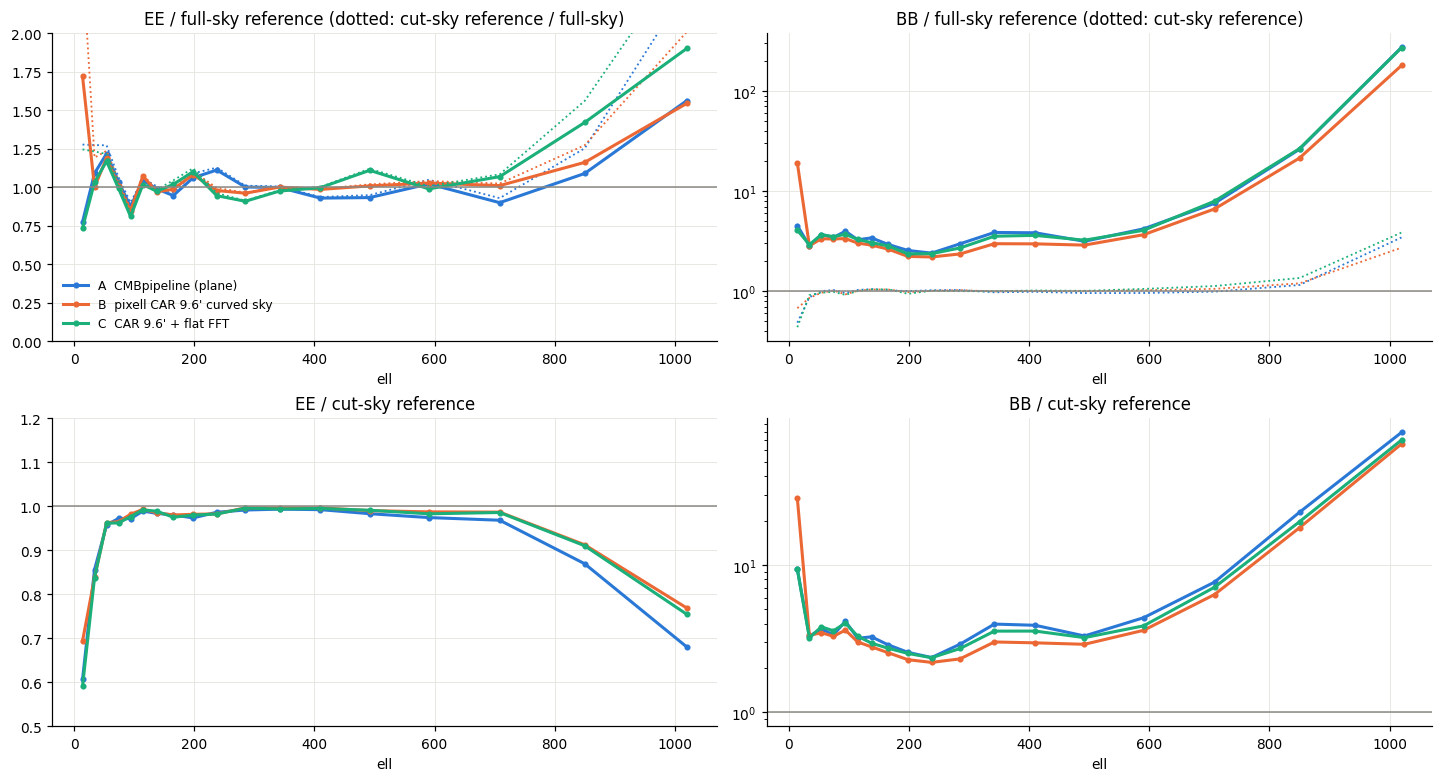

In [24]:
# cut-sky references: true E, B x mask through each pipeline's transform
EE_ref_A, BB_ref_A = spectra_A(EB_true_A[0] * mask2d, EB_true_A[1] * mask2d, bins)
EE_ref_B, BB_ref_B = spectra_B(curvedsky.map2alm(EB_true_B * mask_B, lmax=lmax_car, spin=0), bins)
EE_ref_C, BB_ref_C = spectra_C(enmap.fft(EB_true_C * mask_C, normalize='phys'), bins)
# recovered
EE_A, BB_A = spectra_A(E_pln, B_pln, bins)
EE_B, BB_B = spectra_B(alm_EB, bins)
EE_C, BB_C = spectra_C(harm_C, bins)
EE_full, BB_full = st.bin_cl(cl_real[1], bins), st.bin_cl(cl_real[2], bins)

fig, ax = plt.subplots(2, 2, figsize=(13, 7), constrained_layout=True)
for k, EE, BB, EEr, BBr in (('A', EE_A, BB_A, EE_ref_A, BB_ref_A), ('B', EE_B, BB_B, EE_ref_B, BB_ref_B), ('C', EE_C, BB_C, EE_ref_C, BB_ref_C)):
    ax[0, 0].plot(lb, EE / EE_full, color=COL[k], marker='o', ms=3, label=LAB[k])
    ax[0, 1].plot(lb, BB / BB_full, color=COL[k], marker='o', ms=3, label=LAB[k])
    ax[1, 0].plot(lb, EE / EEr, color=COL[k], marker='o', ms=3, label=LAB[k])
    ax[1, 1].plot(lb, BB / BBr, color=COL[k], marker='o', ms=3, label=LAB[k])
    ax[0, 0].plot(lb, EEr / EE_full, color=COL[k], ls=':', lw=1.2)
    ax[0, 1].plot(lb, BBr / BB_full, color=COL[k], ls=':', lw=1.2)
ax[0, 0].set_title('EE / full-sky reference (dotted: cut-sky reference / full-sky)'); ax[0, 1].set_title('BB / full-sky reference (dotted: cut-sky reference)')
ax[1, 0].set_title('EE / cut-sky reference'); ax[1, 1].set_title('BB / cut-sky reference')
for a in ax.ravel(): a.axhline(1, color='#8a8984', lw=1); a.set_xlabel('ell')
ax[0, 1].set_yscale('log'); ax[1, 1].set_yscale('log'); ax[0, 0].set_ylim(0, 2); ax[1, 0].set_ylim(0.5, 1.2); ax[0, 0].legend(fontsize=8)
plt.savefig(f'{FIGS}/06_recovery_seed1000.png', dpi=150); plt.show()

In [35]:
ele = np.arange(len(clbb))

In [40]:
bl

array([1.00000000e+00, 9.99991928e-01, 9.99975784e-01, ...,
       7.54988253e-05, 7.45697051e-05, 7.36514245e-05], shape=(1536,))

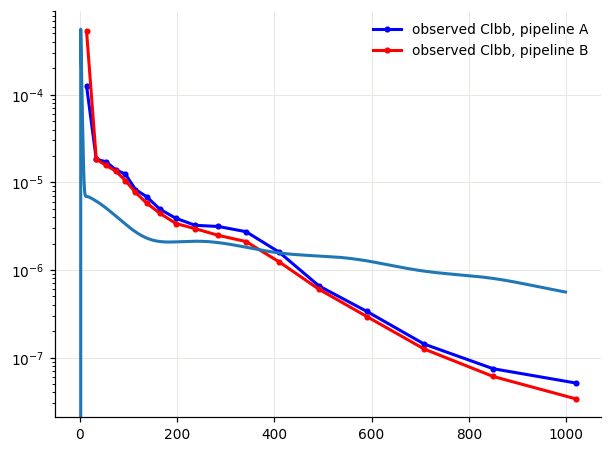

In [44]:
plt.plot(lb, BB_A, 'b.-', label='observed Clbb, pipeline A')
plt.plot(lb, BB_B, 'r.-', label='observed Clbb, pipeline B')

plt.plot(ele[:1000], (clbb[:1000]))#*bl[:1000]**2)
plt.yscale('log')
plt.legend()

In [25]:
# low-ell view (bins of 10)
EE_A_l, BB_A_l = spectra_A(E_pln, B_pln, bins_low);  EEr_A_l, _ = spectra_A(EB_true_A[0]*mask2d, EB_true_A[1]*mask2d, bins_low)
EE_B_l, BB_B_l = spectra_B(alm_EB, bins_low);          EEr_B_l, _ = spectra_B(curvedsky.map2alm(EB_true_B*mask_B, lmax=lmax_car, spin=0), bins_low)
EE_C_l, BB_C_l = spectra_C(harm_C, bins_low);          EEr_C_l, _ = spectra_C(enmap.fft(EB_true_C*mask_C, normalize='phys'), bins_low)
EE_full_l = st.bin_cl(cl_real[1], bins_low)
print(f"{'bin':>9s}{'A/full':>8s}{'B/full':>8s}{'C/full':>8s}{'A/cut':>8s}{'B/cut':>8s}{'C/cut':>8s}")
for i in range(len(lb_low)):
    print(f'{bins_low[i]:3d}-{bins_low[i+1]:<5d}{EE_A_l[i]/EE_full_l[i]:8.3f}{EE_B_l[i]/EE_full_l[i]:8.3f}{EE_C_l[i]/EE_full_l[i]:8.3f}'
          f'{EE_A_l[i]/EEr_A_l[i]:8.3f}{EE_B_l[i]/EEr_B_l[i]:8.3f}{EE_C_l[i]/EEr_C_l[i]:8.3f}')

      bin  A/full  B/full  C/full   A/cut   B/cut   C/cut
  2-12      0.375   0.683   0.338   0.600   0.832   0.570
 12-22      1.966   2.062   1.933   0.818   0.799   0.914
 22-32      1.265   1.204   1.183   0.725   0.739   0.692
 32-42      1.043   0.940   0.905   0.910   0.913   0.859
 42-52      1.138   1.141   1.089   0.932   0.929   0.945
 52-62      1.242   1.211   1.273   0.985   0.983   0.976
 62-72      1.067   1.077   0.934   0.944   0.957   0.947
 72-82      0.990   1.002   1.046   0.971   0.973   0.971
 82-92      0.858   0.777   0.810   0.970   0.969   0.971
 92-102     0.926   0.899   0.805   0.979   0.988   0.979


## 9. Mode mixing

E-only input with power only in ℓ₀ − 2 ≤ ℓ ≤ ℓ₀ + 2 (flat spectrum, no beam), 10 realizations per ℓ₀. The output EE is binned with Δℓ = 4 and normalized to unit sum.

- **Common footprint coupling:** the true E field × mask through each pipeline's transform (cut-sky reference).
- **No-mask control:**
  - A: the plane rectangle is filled from the sphere, mask2d = 1.
  - C: the unmasked patch.
  - B: the unmasked full sky, which returns the input exactly.

In [26]:
l0_list  = [30, 60, 100, 200, 400, 600, 800]
half_w   = 2
n_shell  = 10
bins_mm  = np.arange(0, 1101, 4)
lb_mm    = 0.5 * (bins_mm[1:] + bins_mm[:-1])
nomask   = pa.nomask_setup(geo)                     # all HEALPix pixels inside the plane rectangle
ones_C   = enmap.ones(shape_C, wcs_C)
ones_A   = np.ones((ny, nx))
cache_mm = os.path.join(RESULTS, 'mode_mixing.npz')

def response_one(a):
    # a: shell E-only a_lm (3, nalm). Returns binned EE of every pipeline, cut-sky reference and no-mask control.
    lm = hp.Alm.getlmax(a.shape[-1]); out = {}
    Qs, Us = hp.alm2map(a, nside, lmax=lm, pol=True)[1:]
    Ep, _ = pa.plane_eb(*pa.qu_to_plane(geo, Qs, Us, tri), nx, ny, geo['dx'], geo['dy'])
    out['A'] = st.flat_spectrum_A(ps_A, Ep, ell_flat, bins_mm, w2_A)
    Et = curvedsky.alm2map_pos(a[1], pos=pos_A.reshape(2, -1), spin=0).reshape(ny, nx)
    out['A_ref'] = st.flat_spectrum_A(ps_A, Et * mask2d, ell_flat, bins_mm, w2_A)
    Ep0, _ = pa.plane_eb(*pa.qu_to_plane_nomask(geo, nomask, Qs, Us), nx, ny, geo['dx'], geo['dy'])
    out['A_nomask'] = st.flat_spectrum_A(ps_A, Ep0, ell_flat, bins_mm, 1.0)
    qu = curvedsky.alm2map(a[1:], enmap.zeros((2,) + shape_B, wcs_B), spin=2)
    out['B'] = st.curved_spectrum(curvedsky.map2alm(qu * mask_B, lmax=lmax_car, spin=2)[0], bins_mm, w2_B)
    Eb = curvedsky.alm2map(a[1], enmap.zeros(shape_B, wcs_B), spin=0)
    out['B_ref'] = st.curved_spectrum(curvedsky.map2alm(Eb * mask_B, lmax=lmax_car, spin=0), bins_mm, w2_B)
    out['B_nomask'] = st.curved_spectrum(curvedsky.map2alm(qu, lmax=lmax_car, spin=2)[0], bins_mm, 1.0)
    ar = curvedsky.rotate_alm(a, *angles)
    quc = curvedsky.alm2map(ar[1:], enmap.zeros((2,) + shape_C, wcs_C), spin=2)
    out['C'] = st.flat_spectrum_enmap(enmap.map2harm(quc * mask_C, normalize='phys', spin=[2])[0], modl_C, bins_mm, w2_C)
    Ec = curvedsky.alm2map(ar[1], enmap.zeros(shape_C, wcs_C), spin=0)
    out['C_ref'] = st.flat_spectrum_enmap(enmap.fft(Ec * mask_C, normalize='phys'), modl_C, bins_mm, w2_C)
    out['C_nomask'] = st.flat_spectrum_enmap(enmap.map2harm(quc * ones_C, normalize='phys', spin=[2])[0], modl_C, bins_mm, 1.0)
    return out

if os.path.isfile(cache_mm):
    mm = dict(np.load(cache_mm))
else:
    t0 = time.time(); rows = {}
    for l0 in l0_list:
        for j in range(n_shell):
            o = response_one(si.shell_alm(l0 + half_w, l0, half_w, seed=10000 + 100 * l0 + j))
            for k, v in o.items(): rows.setdefault(f'{k}_{l0}', []).append(v)
        print(f'l0 = {l0}: {time.time() - t0:.0f} s')
    mm = {k: np.array(v) for k, v in rows.items()}
    np.savez(cache_mm, **mm)
print('mode mixing responses:', len(mm), 'arrays of shape', next(iter(mm.values())).shape)

mode mixing responses: 63 arrays of shape (10, 275)


width (84-16 %)
   l0         A         B         C     A_ref     B_ref     C_ref  A_nomask  B_nomask  C_nomask
   30      7.92      7.12      7.12      8.40      7.69      7.86      7.49      4.35      6.91
   60      7.41      6.76      8.25      7.63      6.94      8.53      7.99      5.35      7.54
  100      9.05      6.74      9.24      9.36      6.85      9.43     10.03      5.36      9.31
  200     14.76      6.85     12.74     15.06      6.92     12.90     16.71      5.34     14.80
  400     24.94      6.84     21.89     25.31      6.89     22.21     31.51      5.33     27.32
  600     36.47      6.87     31.62     36.80      6.90     31.90     46.94      5.34     38.85
  800     48.54      6.86     39.61     48.57      6.88     39.90     62.46      5.33     49.81

centroid shift <l> - l0
   l0         A         B         C     A_ref     B_ref     C_ref  A_nomask  B_nomask  C_nomask
   30      0.20      0.71      0.84      0.26      0.73      0.85     -0.11      0.91      0.54

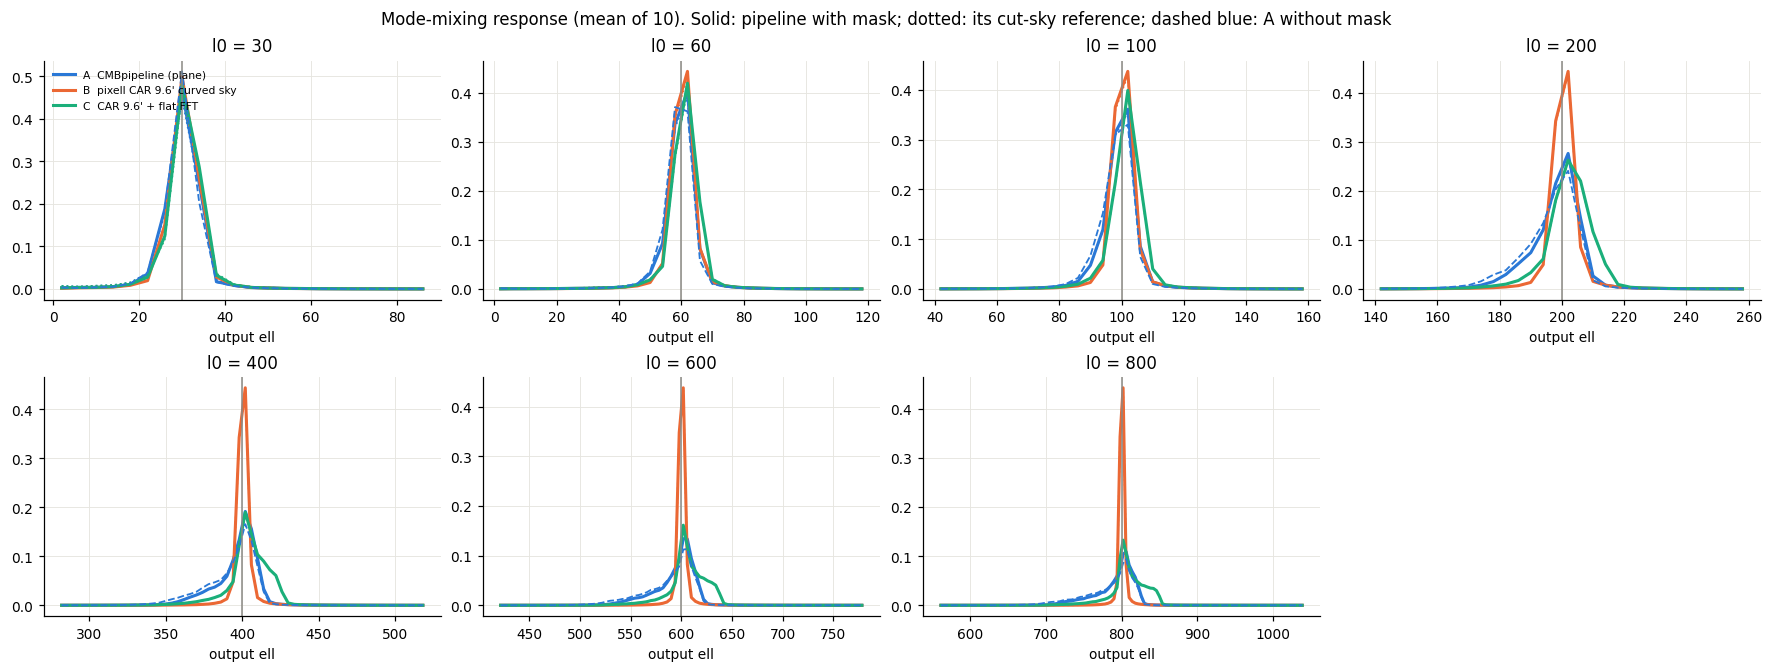

In [27]:
keys = ['A', 'B', 'C', 'A_ref', 'B_ref', 'C_ref', 'A_nomask', 'B_nomask', 'C_nomask']
stats = {(k, l0): st.response_stats(lb_mm, mm[f'{k}_{l0}'].mean(0), l0) for k in keys for l0 in l0_list}
for q, name in (('width', 'width (84-16 %)'), ('shift', 'centroid shift <l> - l0'), ('out20', 'fraction outside l0 +- 20')):
    print(name)
    print(f"{'l0':>5s}" + ''.join(f'{k:>10s}' for k in keys))
    for l0 in l0_list:
        print(f'{l0:5d}' + ''.join(f'{stats[(k, l0)][q]:10.2f}' for k in keys))
    print()

fig, ax = plt.subplots(2, 4, figsize=(16, 6), constrained_layout=True)
for a, l0 in zip(ax.ravel(), l0_list):
    sel = np.abs(lb_mm - l0) < max(60, 0.3 * l0)
    for k in ('A', 'B', 'C'):
        r = mm[f'{k}_{l0}'].mean(0); a.plot(lb_mm[sel], (r / r.sum())[sel], color=COL[k], label=LAB[k])
        r = mm[f'{k}_ref_{l0}'].mean(0); a.plot(lb_mm[sel], (r / r.sum())[sel], color=COL[k], ls=':', lw=1.2)
    r = mm[f'A_nomask_{l0}'].mean(0); a.plot(lb_mm[sel], (r / r.sum())[sel], color=COL['A'], ls='--', lw=1.2)
    a.axvline(l0, color='#8a8984', lw=1); a.set_title(f'l0 = {l0}'); a.set_xlabel('output ell')
ax.ravel()[-1].axis('off')
ax[0, 0].legend(fontsize=7, loc='upper left')
fig.suptitle('Mode-mixing response (mean of 10). Solid: pipeline with mask; dotted: its cut-sky reference; dashed blue: A without mask')
plt.savefig(f'{FIGS}/07_mode_mixing.png', dpi=150); plt.show()

## 10. Statistical validation (N = 50 realizations)

The same seeds go through all pipelines, with the full input for recovery and the E-only input for leakage. Differences are *paired* per realization, and a difference is called systematic if |mean| > 3 standard errors.

Diagnostics:
- **A′**: A's maps with dx = dy = 9.6′ (the real grid pitch).
- **B 6′**: the control grid.

In [28]:
# A' (FFT with the true pitch)
ps_Ap = PP.PowerSpectrum(nside, nx, ny, geo['pix'], geo['pix'], fwhm_arcmin, len(bins) - 1, bins, 1.0, 5e-7)
ell_flat_Ap, _ = ps_Ap.flat_spectrum_xy(clee)
cache_ens = os.path.join(RESULTS, f'ensemble_N{nsims}.npz')

def one_seed(seed):
    out = {}
    for comp in ('full', 'E'):
        a = si.make_alm(cltt, clee, clbb, lmax, fwhm_arcmin, seed, comp)
        Qs, Us = hp.alm2map(a, nside, lmax=lmax, pol=True)[1:]
        Qp, Up = pa.qu_to_plane(geo, Qs, Us, tri)
        Ep, Bp = pa.plane_eb(Qp, Up, nx, ny, geo['dx'], geo['dy'])
        out[f'A_{comp}'] = np.array(spectra_A(Ep, Bp, bins))
        Ep1, Bp1 = pa.plane_eb(Qp, Up, nx, ny, geo['pix'], geo['pix'])
        out[f'Ap_{comp}'] = np.array([st.flat_spectrum_A(ps_Ap, m, ell_flat_Ap, bins, w2_A) for m in (Ep1, Bp1)])
        qu = curvedsky.alm2map(a[1:], enmap.zeros((2,) + shape_B, wcs_B), spin=2)
        out[f'B_{comp}'] = np.array(spectra_B(curvedsky.map2alm(qu * mask_B, lmax=lmax_car, spin=2), bins))
        qu6 = curvedsky.alm2map(a[1:], enmap.zeros((2,) + shape_B6, wcs_B6), spin=2)
        out[f'B6_{comp}'] = np.array(spectra_B(curvedsky.map2alm(qu6 * mask_B6, lmax=lmax_ctl, spin=2), bins, w2_B6))
        ar = curvedsky.rotate_alm(a, *angles)
        quc = curvedsky.alm2map(ar[1:], enmap.zeros((2,) + shape_C, wcs_C), spin=2)
        out[f'C_{comp}'] = np.array(spectra_C(enmap.map2harm(quc * mask_C, normalize='phys', spin=[2]), bins))
        if comp == 'full':        # cut-sky references and full-sky reference
            EBt = curvedsky.alm2map_pos(a[1:], pos=pos_A.reshape(2, -1), spin=0).reshape(2, ny, nx)
            out['A_ref'] = np.array(spectra_A(EBt[0] * mask2d, EBt[1] * mask2d, bins))
            out['Ap_ref'] = np.array([st.flat_spectrum_A(ps_Ap, m * mask2d, ell_flat_Ap, bins, w2_A) for m in EBt])
            EBb = curvedsky.alm2map(a[1:], enmap.zeros((2,) + shape_B, wcs_B), spin=0)
            out['B_ref'] = np.array(spectra_B(curvedsky.map2alm(EBb * mask_B, lmax=lmax_car, spin=0), bins))
            EBb6 = curvedsky.alm2map(a[1:], enmap.zeros((2,) + shape_B6, wcs_B6), spin=0)
            out['B6_ref'] = np.array(spectra_B(curvedsky.map2alm(EBb6 * mask_B6, lmax=lmax_ctl, spin=0), bins, w2_B6))
            EBc = curvedsky.alm2map(ar[1:], enmap.zeros((2,) + shape_C, wcs_C), spin=0)
            out['C_ref'] = np.array(spectra_C(enmap.fft(EBc * mask_C, normalize='phys'), bins))
            cl = curvedsky.alm2cl(a)
            out['full_ref'] = np.array([st.bin_cl(cl[1], bins), st.bin_cl(cl[2], bins)])
    return out

if os.path.isfile(cache_ens):
    ens = dict(np.load(cache_ens))
else:
    t0 = time.time(); rows = []
    for s_ in seeds:
        rows.append(one_seed(s_))
        if (s_ - seeds[0]) % 10 == 9: print(f'{s_ - seeds[0] + 1} seeds: {time.time() - t0:.0f} s')
    ens = {k: np.array([r[k] for r in rows]) for k in rows[0]}
    np.savez(cache_ens, **ens)
print({k: v.shape for k, v in ens.items()})       # (nsims, 2 = EE/BB, nbins)

{'A_full': (50, 2, 18), 'Ap_full': (50, 2, 18), 'B_full': (50, 2, 18), 'B6_full': (50, 2, 18), 'C_full': (50, 2, 18), 'A_ref': (50, 2, 18), 'Ap_ref': (50, 2, 18), 'B_ref': (50, 2, 18), 'B6_ref': (50, 2, 18), 'C_ref': (50, 2, 18), 'full_ref': (50, 2, 18), 'A_E': (50, 2, 18), 'Ap_E': (50, 2, 18), 'B_E': (50, 2, 18), 'B6_E': (50, 2, 18), 'C_E': (50, 2, 18)}


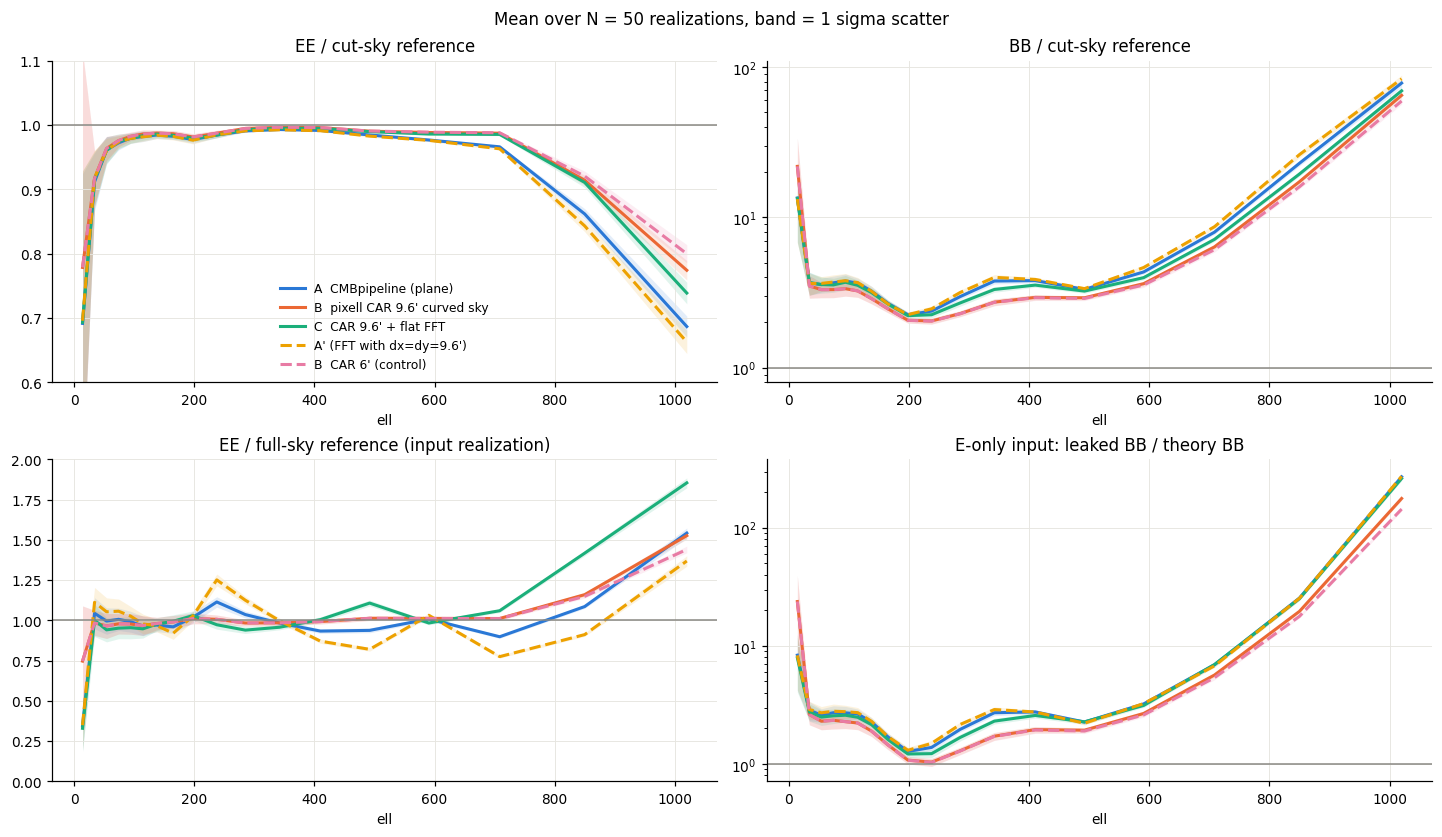

In [29]:
P = ['A', 'B', 'C', 'Ap', 'B6']
EE, BB = 0, 1
def band(ax, k, y, ls='-'):
    ax.plot(lb, y.mean(0), color=COL[k], ls=ls, label=LAB[k])
    ax.fill_between(lb, y.mean(0) - y.std(0), y.mean(0) + y.std(0), color=COL[k], alpha=0.13, lw=0)

fig, ax = plt.subplots(2, 2, figsize=(13, 7.5), constrained_layout=True)
for k in P:
    band(ax[0, 0], k, ens[f'{k}_full'][:, EE] / ens[f'{k}_ref'][:, EE], '--' if k in ('Ap', 'B6') else '-')
    band(ax[0, 1], k, ens[f'{k}_full'][:, BB] / ens[f'{k}_ref'][:, BB], '--' if k in ('Ap', 'B6') else '-')
    band(ax[1, 0], k, ens[f'{k}_full'][:, EE] / ens['full_ref'][:, EE], '--' if k in ('Ap', 'B6') else '-')
    band(ax[1, 1], k, ens[f'{k}_E'][:, BB] / bb_th, '--' if k in ('Ap', 'B6') else '-')
ax[0, 0].set_title('EE / cut-sky reference'); ax[0, 1].set_title('BB / cut-sky reference')
ax[1, 0].set_title('EE / full-sky reference (input realization)'); ax[1, 1].set_title('E-only input: leaked BB / theory BB')
ax[0, 0].set_ylim(0.6, 1.1); ax[1, 0].set_ylim(0, 2); ax[0, 1].set_yscale('log'); ax[1, 1].set_yscale('log')
for a in ax.ravel(): a.axhline(1, color='#8a8984', lw=1); a.set_xlabel('ell')
ax[0, 0].legend(fontsize=8)
fig.suptitle(f'Mean over N = {nsims} realizations, band = 1 sigma scatter')
plt.savefig(f'{FIGS}/08_ensemble.png', dpi=150); plt.show()

In [30]:
# paired differences A - B and C - B (same realizations), in units of the standard error
def paired_table(title, fa, fb, fc):
    dA, eA, zA = st.paired(fa, fb); dC, eC, zC = st.paired(fc, fb)
    print(title); print(f"{'bin':>10s}{'B':>9s}{'A - B':>9s}{'(sigma)':>9s}{'C - B':>9s}{'(sigma)':>9s}")
    for i in range(len(lb)):
        print(f'{bins[i]:4d}-{bins[i+1]:<5d}{fb.mean(0)[i]:9.3f}{dA[i]:9.3f}{zA[i]:9.1f}{dC[i]:9.3f}{zC[i]:9.1f}')
    print()
ratio = lambda k, i: ens[f'{k}_full'][:, i] / ens[f'{k}_ref'][:, i]
paired_table('EE / cut-sky reference', ratio('A', EE), ratio('B', EE), ratio('C', EE))
paired_table('BB / cut-sky reference', ratio('A', BB), ratio('B', BB), ratio('C', BB))
leak_rel = lambda k: ens[f'{k}_E'][:, BB] / bb_th
paired_table('E-only: leaked BB / theory BB', leak_rel('A'), leak_rel('B'), leak_rel('C'))

EE / cut-sky reference
       bin        B    A - B  (sigma)    C - B  (sigma)
   4-24       0.778   -0.087     -3.5   -0.085     -3.2
  24-44       0.917   -0.006     -2.0   -0.002     -0.6
  44-64       0.963   -0.002     -1.9   -0.003     -2.5
  64-84       0.976   -0.003     -4.5   -0.001     -1.3
  84-104      0.982   -0.003     -3.7   -0.003     -4.7
 104-125      0.986   -0.004     -6.0   -0.003     -4.4
 125-150      0.987   -0.003     -6.7   -0.002     -4.4
 150-180      0.986   -0.004     -8.3   -0.002     -5.9
 180-216      0.981   -0.004     -7.3   -0.002     -4.4
 216-259      0.987   -0.003     -7.2   -0.003     -7.8
 259-311      0.994   -0.004    -20.9   -0.002    -11.4
 311-373      0.996   -0.003    -31.7   -0.002    -14.2
 373-447      0.996   -0.004    -43.8   -0.001    -12.4
 447-537      0.990   -0.006    -35.1   -0.001     -5.1
 537-644      0.988   -0.012    -75.0   -0.002    -14.2
 644-773      0.987   -0.021    -93.0   -0.002    -11.0
 773-927      0.914   -0.

## 11. Computational time (one realization, seed 1000)

In [31]:
print(f"{'pipeline':44s}{'time [s]':>10s}")
print(f"{'A  alm2map (HEALPix)':44s}{t_A1:10.2f}")
print(f"{'A  rotate + project + interpolate (griddata)':44s}{t_A2_griddata:10.2f}")
print(f"{'A  rotate + project + interpolate (cached)':44s}{t_A2:10.2f}")
print(f"{'A  flat FFT E/B':44s}{t_A3:10.3f}")
print(f"{'B  alm2map (CAR 9.6)':44s}{t_B1:10.2f}")
print(f"{'B  map2alm spin 2':44s}{t_B2:10.2f}")
print(f"{'C  rotate_alm + alm2map + map2harm':44s}{t_C:10.2f}")
print(f"{'B on the cut-out (alm2map + map2alm + alm2map)':44s}{t_Bcut:10.2f}")
print()
print(f"total to E/B:  A (as CMBpipeline) {t_A1 + t_A2_griddata + t_A3:.2f} s | A (cached) {t_A1 + t_A2 + t_A3:.2f} s | B {t_B1 + t_B2:.2f} s | C {t_C:.2f} s")

pipeline                                      time [s]
A  alm2map (HEALPix)                              0.51
A  rotate + project + interpolate (griddata)      8.74
A  rotate + project + interpolate (cached)        2.81
A  flat FFT E/B                                  0.023
B  alm2map (CAR 9.6)                              0.24
B  map2alm spin 2                                 0.21
C  rotate_alm + alm2map + map2harm                1.10
B on the cut-out (alm2map + map2alm + alm2map)      0.37

total to E/B:  A (as CMBpipeline) 9.27 s | A (cached) 3.34 s | B 0.45 s | C 1.10 s


## 12. Summary numbers

In [32]:
def avg(y, lo, hi):
    s = (lb >= lo) & (lb < hi); return y.mean(0)[s].mean()
print(f"{'':26s}{'EE/cut':>9s}{'EE/cut':>9s}{'BB/cut':>9s}{'leak/BBth':>11s}{'leak/BBth':>11s}{'leak/BBth':>11s}")
print(f"{'ell range':26s}{'50-300':>9s}{'300-800':>9s}{'50-300':>9s}{'<50':>11s}{'50-300':>11s}{'300-800':>11s}")
for k in P:
    print(f"{LAB[k]:26s}{avg(ratio(k, EE), 50, 300):9.3f}{avg(ratio(k, EE), 300, 800):9.3f}{avg(ratio(k, BB), 50, 300):9.2f}"
          f"{avg(leak_rel(k), 0, 50):11.2f}{avg(leak_rel(k), 50, 300):11.2f}{avg(leak_rel(k), 300, 800):11.2f}")
print()
print('mode mixing, width (84-16 %) of the response:')
print(f"{'l0':>5s}{'A':>8s}{'B':>8s}{'C':>8s}{'A ref':>8s}{'B ref':>8s}{'A nomask':>10s}{'C nomask':>10s}")
for l0 in l0_list:
    print(f"{l0:5d}" + ''.join(f"{stats[(k, l0)]['width']:8.1f}" for k in ('A', 'B', 'C', 'A_ref', 'B_ref'))
          + ''.join(f"{stats[(k, l0)]['width']:10.1f}" for k in ('A_nomask', 'C_nomask')))

                             EE/cut   EE/cut   BB/cut  leak/BBth  leak/BBth  leak/BBth
ell range                    50-300  300-800   50-300        <50     50-300    300-800
A  CMBpipeline (plane)        0.979    0.982     3.13       5.60       2.14       3.58
B  pixell CAR 9.6' curved sky    0.983    0.991     2.77      13.19       1.77       2.79
C  CAR 9.6' + flat FFT        0.980    0.990     3.04       5.36       2.00       3.45
A' (FFT with dx=dy=9.6')      0.979    0.981     3.17       5.60       2.22       3.58
B  CAR 6' (control)           0.983    0.992     2.77      13.20       1.77       2.71

mode mixing, width (84-16 %) of the response:
   l0       A       B       C   A ref   B ref  A nomask  C nomask
   30     7.9     7.1     7.1     8.4     7.7       7.5       6.9
   60     7.4     6.8     8.2     7.6     6.9       8.0       7.5
  100     9.1     6.7     9.2     9.4     6.9      10.0       9.3
  200    14.8     6.9    12.7    15.1     6.9      16.7      14.8
  400    24